<a href="https://colab.research.google.com/github/pop123-ux/HuggingFace-Project-Learning/blob/main/course/chapter3/Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Implementing Custom Evaluations ##

We can use lighteval to evaluate the finetuned model on standard benchmarks, which contain a wide range of tasks built into the library. We just need to define the tasks we want to evaluate and the parameters for the evalutation

LightEval tasks are defined using a specific format:

{suite}|{task}|{num_few_shot}|{auto_reduce}
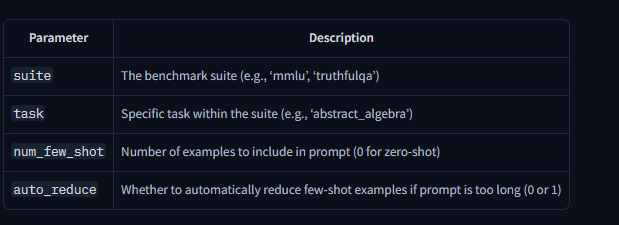

For example, "mmlu|abstract_algebra|0|0" evaluates on MMLU's abstract algebra task with zero-shot inference.

## Example Evaluation Pipeline ##

Let's set up an evaluation pipeline for our finetuned model. We will evaluate the model on set of sub tasks that relate to the domain of medicine.

Here's a complete example of evaluating on automatic benchmarks relevant to one specific domain using Lighteval with the VLLM backend:

In [ ]:
lighteval accelerate \
    "pretrained=your-model-name" \
    "mmlu|anatomy|0|0" \
    "mmlu|high_school_biology|0|0" \
    "mmlu|high_school_chemistry|0|0" \
    "mmlu|professional_medicine|0|0" \
    --max_samples 40 \
    --batch_size 1 \
    --output_path "./results" \
    --save_generations true

Results are displayed in a tabular format showing:

In [ ]:
|                  Task                  |Version|Metric|Value |   |Stderr|
|----------------------------------------|------:|------|-----:|---|-----:|
|all                                     |       |acc   |0.3333|±  |0.1169|
|leaderboard:mmlu:_average:5             |       |acc   |0.3400|±  |0.1121|
|leaderboard:mmlu:anatomy:5              |      0|acc   |0.4500|±  |0.1141|
|leaderboard:mmlu:high_school_biology:5  |      0|acc   |0.1500|±  |0.0819|

Lighteval also include a python API for more detailed evaluation tasks, which is useful for manipulating the results in a more flexible way.